# Notebook 3 — Customer Lifetime Value (LightGBM)

**Goal:** Predict CLV for every customer, segment by value tier, write to PostgreSQL.

**Prerequisite:** Notebooks 1 and 2 must have been run first.

---

### Steps in this notebook
1. Understand the monetary (CLV) distribution
2. Why we log-transform the target
3. Train LightGBM model (via `src\train_clv.py`)
4. CLV segment analysis
5. Combined Churn × CLV view (feeds Power BI)
6. Project complete — Power BI checklist

In [15]:
import sys
sys.path.append('../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.features import build_feature_matrix, get_rfm_segments, CLV_TARGET
from src.db import engine

plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK.')

Imports OK.


## Step 1 — Understand the monetary distribution

In [16]:
df = build_feature_matrix()
df = get_rfm_segments(df)

print('Monetary (total spend per customer) stats:')
print(df[CLV_TARGET].describe().round(2))

Pulling RFM features ...
Pulling review features ...
Pulling category features ...
Feature matrix: 93,357 customers | churn rate 24.9%
Monetary (total spend per customer) stats:
count    93357.00
mean       165.20
std        226.31
min          9.59
25%         63.06
50%        107.78
75%        182.56
max      13664.08
Name: monetary, dtype: float64


## Step 2 — Why log-transform? (right-skewed target)

None


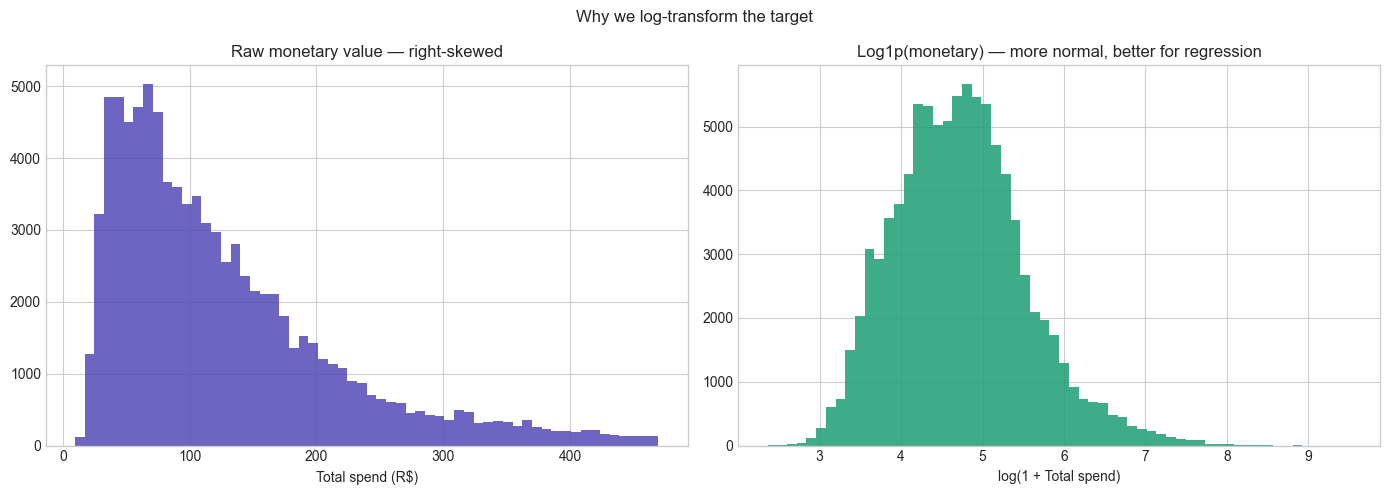

The right plot is much closer to a normal distribution.
LightGBM predictions will be back-transformed with np.expm1().


In [24]:
import os

print(os.chdir('C:/Users/dell/OneDrive/Desktop/ecommerce_intelligence/notebooks/03_clv'))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
p95 = df[CLV_TARGET].quantile(0.95)

axes[0].hist(df[df[CLV_TARGET] <= p95][CLV_TARGET],
             bins=60, color='#534AB7', edgecolor='none', alpha=0.85)
axes[0].set_title('Raw monetary value — right-skewed')
axes[0].set_xlabel('Total spend (R$)')

axes[1].hist(np.log1p(df[CLV_TARGET]),
             bins=60, color='#1D9E75', edgecolor='none', alpha=0.85)
axes[1].set_title('Log1p(monetary) — more normal, better for regression')
axes[1].set_xlabel('log(1 + Total spend)')

plt.suptitle('Why we log-transform the target', fontsize=12)
plt.tight_layout()
plt.savefig('../../docs/screenshots/09_clv_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print('The right plot is much closer to a normal distribution.')
print('LightGBM predictions will be back-transformed with np.expm1().')

## Step 3 — Train CLV Model

This calls `src\train_clv.py` which:
- Log-transforms the monetary target
- Trains LightGBM with early stopping
- Logs MAE, RMSE, R², MAPE + SHAP plots to MLflow
- Writes predictions to `ml_clv_predictions` table in PostgreSQL

In [25]:
import os
print(os.getcwd())

C:\Users\dell\OneDrive\Desktop\ecommerce_intelligence\notebooks\03_clv


In [30]:
import os

os.chdir(r"C:/Users/dell/OneDrive/Desktop/ecommerce_intelligence")

print(os.getcwd())

from src.train_clv import train_clv_model

model = train_clv_model()
print('\nCLV training complete. Check http://localhost:5000')

C:\Users\dell\OneDrive\Desktop\ecommerce_intelligence


ModuleNotFoundError: No module named 'src.train_clv'